In [21]:
print("Name: Divyadharshini S\nRoll no:24BAD022")
import numpy as np
import tensorflow as tf
import requests
import re
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
if response.status_code == 200:
    text = response.text
    print("Tiny Shakespeare dataset loaded successfully!")
else:
    raise Exception("Failed to download dataset.")

print("\nTotal Characters:", len(text))
print("\nSample Text:")
print(text[:1000])

text = text.lower()
print("\nLowercase Text Sample:")
print(text[:500])

text_clean = re.sub(r"[^\w\s]", "", text)
words = text_clean.split()
print("\nTotal Number of Words:", len(words))
print("\nFirst 20 Tokens:")
print(words[:20])

vocab = sorted(set(words))
word_to_index = {
    word: index + 1
    for index, word in enumerate(vocab)
}
index_to_word = {
    index: word
    for word, index in word_to_index.items()
}

vocab_size = len(word_to_index) + 1
print("\nVocabulary Size:", vocab_size)
print("\nSample Vocabulary:")
for word in list(word_to_index.keys())[:20]:
    print(word, ":", word_to_index[word])

encoded_words = [
    word_to_index[word]
    for word in words
]
print("\nFirst 20 Words:")
print(words[:20])
print("\nFirst 20 Numerical Values:")
print(encoded_words[:20])

SEQUENCE_LENGTH = 20
sequences = []
targets = []

for i in range(1, len(encoded_words)):
    start = max(0, i - SEQUENCE_LENGTH)
    sequence = encoded_words[start:i]
    target = encoded_words[i]
    sequences.append(sequence)
    targets.append(target)
print("\nTotal Sequences:", len(sequences))

X = tf.keras.utils.pad_sequences(
    sequences,
    maxlen=SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre"
)
y = np.array(targets)

print("\nAfter Padding:")
print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("DATASET SPLIT\n")

print("Training Input Shape   :", X_train.shape)
print("Training Target Shape  :", y_train.shape)

print("Validation Input Shape :", X_val.shape)
print("Validation Target Shape:", y_val.shape)

print("\nTraining Samples   :", len(X_train))
print("Validation Samples:", len(X_val))


Name: Divyadharshini S
Roll no:24BAD022
Tiny Shakespeare dataset loaded successfully!

Total Characters: 1115394

Sample Text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us rev

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

EMBEDDING_DIM = 128
RNN_UNITS = 128

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),
    SimpleRNN(
        RNN_UNITS,
        return_sequences=False
    ),
    Dense(
        vocab_size,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.build(input_shape=(None, SEQUENCE_LENGTH))

print("RNN MODEL ARCHITECTURE")
model.summary()

RNN MODEL ARCHITECTURE


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 20, 128)        │     1,644,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12849)          │     1,657,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,335,089 (12.72 MB)

 Trainable params: 3,335,089 (12.72 MB)

 Non-trainable params: 0 (0.00 B)

STARTING RNN TRAINING
Epoch 1/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.0467 - loss: 6.7383 - val_accuracy: 0.0719 - val_loss: 6.4179
Epoch 2/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0839 - loss: 6.1041 - val_accuracy: 0.0856 - val_loss: 6.2842
Epoch 3/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.0980 - loss: 5.7694 - val_accuracy: 0.0913 - val_loss: 6.2695
Epoch 4/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1108 - loss: 5.4795 - val_accuracy: 0.0906 - val_loss: 6.3060
Epoch 5/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.1238 - loss: 5.2142 - val_accuracy: 0.0909 - val_loss: 6.3758
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
MODEL PERFORMANCE
Training Accuracy   : 11.31 %
Validation Accuracy : 9.13 %
Training Loss       : 5.3843
Validation Loss     : 6.2695


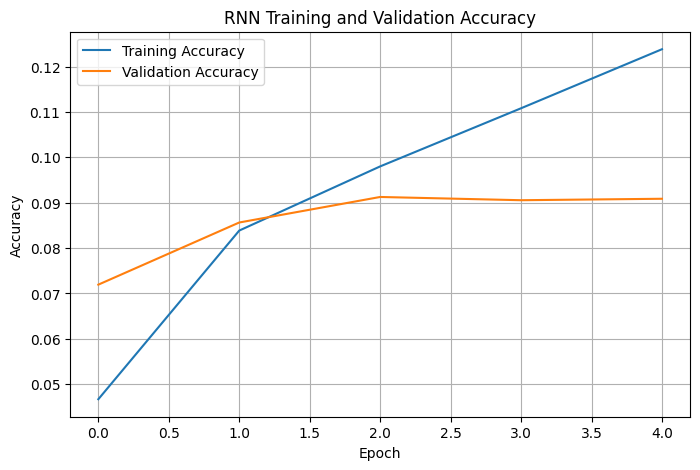

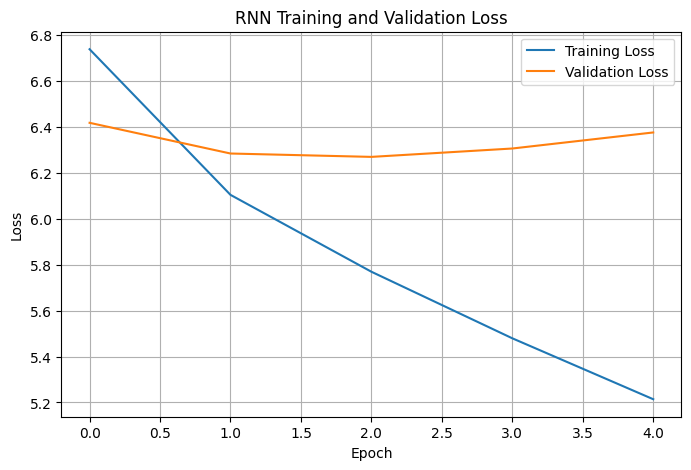

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 20
BATCH_SIZE = 128

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

print("STARTING RNN TRAINING")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("MODEL PERFORMANCE")
print(f"Training Accuracy   : {train_accuracy * 100:.2f} %")
print(f"Validation Accuracy : {val_accuracy * 100:.2f} %")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("RNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import numpy as np
import tensorflow as tf
import re

def generate_text(seed_text, num_words=25, temperature=0.8):
    seed_text = seed_text.lower()
    seed_text = re.sub(r"[^\w\s]", "", seed_text)
    seed_words = seed_text.split()

    seed_words = [
        word for word in seed_words
        if word in word_to_index
    ]

    if len(seed_words) == 0:
        return "Seed words are not present in the vocabulary."
    generated_words = seed_words.copy()

    for _ in range(num_words):
        current_words = generated_words[-SEQUENCE_LENGTH:]
        encoded = [
            word_to_index[word]
            for word in current_words
        ]
        padded = tf.keras.utils.pad_sequences(
            [encoded],
            maxlen=SEQUENCE_LENGTH,
            padding="pre",
            truncating="pre"
        )
        prediction = model.predict(
            padded,
            verbose=0
        )[0]

        prediction = np.asarray(prediction).astype("float64")
        prediction = np.log(prediction + 1e-8) / temperature
        exp_prediction = np.exp(
            prediction - np.max(prediction)
        )
        probabilities = exp_prediction / np.sum(exp_prediction)
        predicted_index = np.random.choice(
            len(probabilities),
            p=probabilities
        )
        predicted_word = index_to_word.get(
            predicted_index,
            ""
        )
        if predicted_word == "":
            break
        generated_words.append(predicted_word)
    return " ".join(generated_words)

seeds = [
    "the king",
    "my lord",
    "love is",
    "to be",
    "when i"
]

print("GENERATED TEXT")
for seed in seeds:
    generated = generate_text(
        seed,
        num_words=25,
        temperature=0.8
    )
    print("\nSeed:", seed)
    print("Generated Text:")
    print(generated)

GENERATED TEXT

Seed: the king
Generated Text:
the king edward is in his blood and a converts and else i heard antigonus i would bear me yield me come tis lie thy head come

Seed: my lord
Generated Text:
my lord but all the point of thy face to be in hereford grey than he is thine and a whit to drink the world what you

Seed: love is
Generated Text:
love is pang the day of lesser than a prophecy to commanded and sometime my tongue might mean my masters o this account not i beseech the

Seed: to be
Generated Text:
to be out of they do not so much and let me hither the welcome hie i have met for all second citizen menenius what is the

Seed: when i
Generated Text:
when i can change this ignorant and quite of sizes of a part as they seeks to this king henry vi thine soul i doubt not put
